# Data Objects

To begin with, as we have seen in the prvious chapter, we have to express what to analyze, the data. We will introduce some basic data objects here.

## Learning Points

In this chapter, you will learn about:

* Importing necessary modules
* SEC-SAXS data objects
* How to plot data
* Elution curves
* Scattering curves

## SEC-SAXS Data



In [1]:
from molass import get_version
assert get_version() >= '0.1.0', "This tutorial requires molass version 0.1.0 or higher."
import matplotlib.pyplot as plt
from molass_data import SAMPLE1

The following code loads the SEC-SAXS data and displays a 3D plot of the dataset. This helps visualize the relationship between elution time, scattering angle, and intensity.

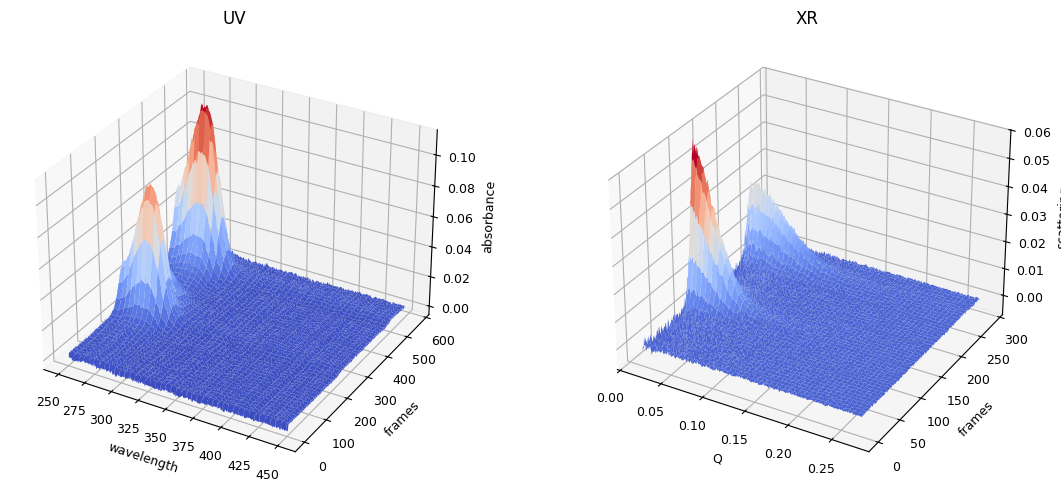

In [2]:
from molass.DataObjects import SecSaxsData as SSD
ssd = SSD(SAMPLE1)
ssd.plot_3d();

You should see a 3D plot representing the SEC-SAXS data. This visualization helps you understand the structure of the data and how it changes over time.

## Elution Curves

An **elution curve** shows how the signal (such as absorbance or scattering intensity) changes as a function of elution time or volume during a chromatography experiment. In SEC-SAXS, you often look at both UV absorbance and X-ray scattering elution curves.

Let's extract and plot the elution curves for both X-ray scattering and UV absorbance.

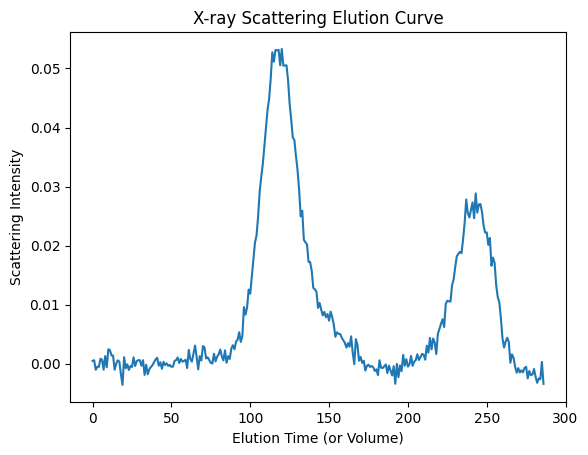

In [3]:
xr_icurve = ssd.xr.get_icurve()
plt.plot(xr_icurve.x, xr_icurve.y)
plt.title('X-ray Scattering Elution Curve')
plt.xlabel('Elution Time (or Volume)')
plt.ylabel('Scattering Intensity')
plt.show()

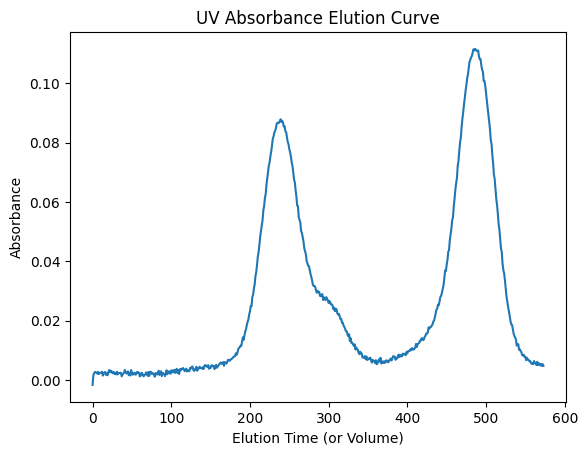

In [4]:
uv_icurve = ssd.uv.get_icurve()
plt.plot(uv_icurve.x, uv_icurve.y)
plt.title('UV Absorbance Elution Curve')
plt.xlabel('Elution Time (or Volume)')
plt.ylabel('Absorbance')
plt.show()

You should see two plots: one for the X-ray scattering elution curve and one for the UV absorbance elution curve.

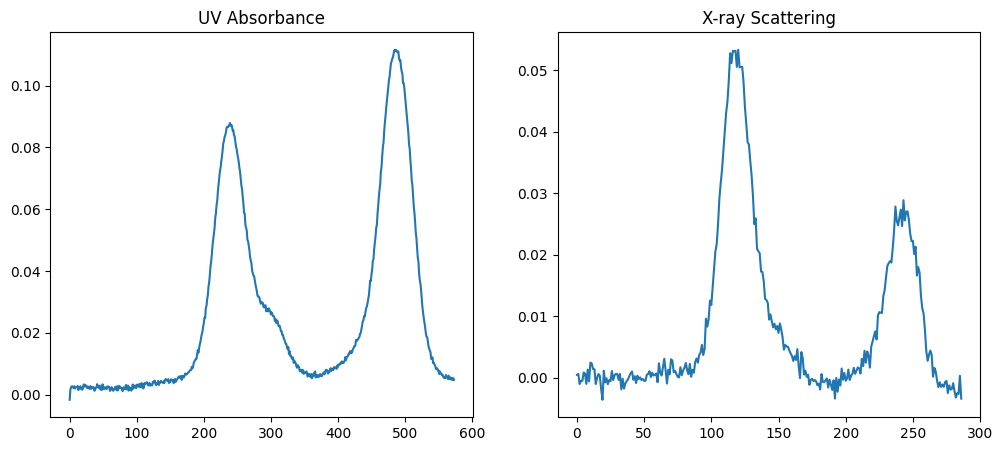

In [5]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
ax1.plot(uv_icurve.x, uv_icurve.y)
ax1.set_title('UV Absorbance')
ax2.plot(xr_icurve.x, xr_icurve.y)
ax2.set_title('X-ray Scattering')
plt.show()

## Peak Positions

To analyze the data further, let's find the peak positions in both elution curves. We use **integer array indexing** for NumPy arrays to highlight the peaks.

In [6]:
uv_peaks = uv_icurve.get_peaks()
xr_peaks = xr_icurve.get_peaks()
uv_peaks, xr_peaks

([239, 486], [120, 243])

Now, let's plot the elution curves again and mark the peak positions.

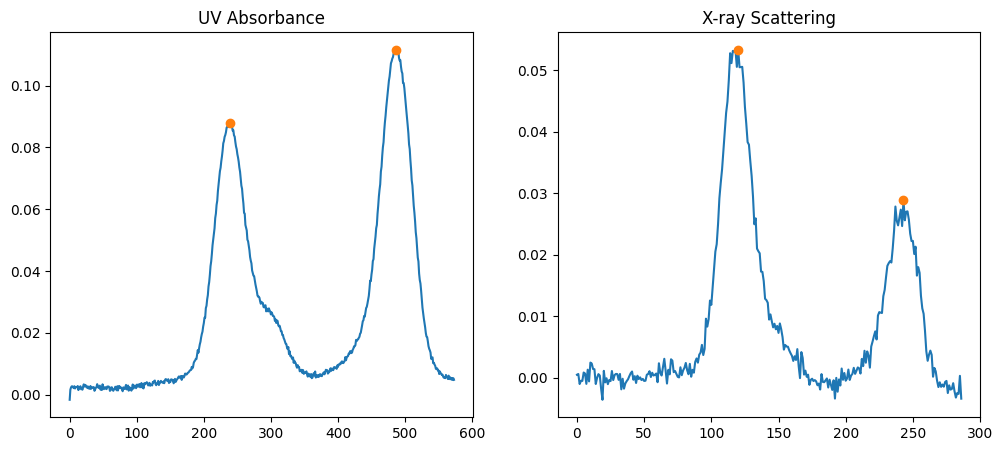

In [7]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
ax1.plot(uv_icurve.x, uv_icurve.y)
ax1.plot(uv_icurve.x[uv_peaks], uv_icurve.y[uv_peaks], 'o', label='Peaks')
ax1.set_title('UV Absorbance')
ax2.plot(xr_icurve.x, xr_icurve.y)
ax2.plot(xr_icurve.x[xr_peaks], xr_icurve.y[xr_peaks], 'o', label='Peaks')
ax2.set_title('X-ray Scattering')
plt.show()

The circles on the plots indicate the detected peak positions.

* [Colors in the default property cycle](https://matplotlib.org/stable/gallery/color/color_cycle_default.html)

## Spectral Curves

```{note}
Here, we use "spectral" to mean either of the following two types of curves, for simplicity.
```

### Absorbance Curves

For each detected peak in the UV absorbance elution curve, let's plot the corresponding absorbance curve.

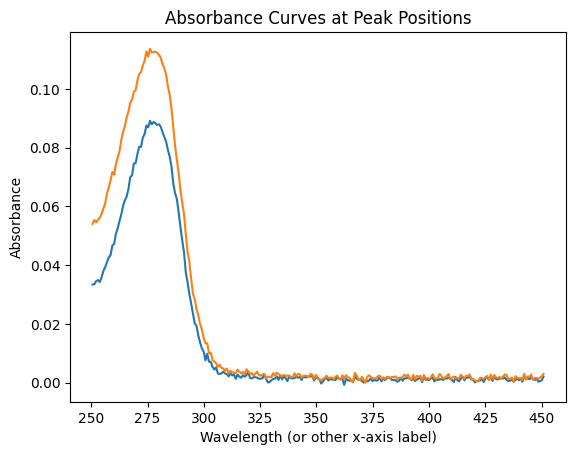

In [8]:
for j in uv_peaks:
    uv_jcurve = ssd.uv.get_jcurve(j=j)
    plt.plot(uv_jcurve.x, uv_jcurve.y)
plt.title('Absorbance Curves at Peak Positions')
plt.xlabel('Wavelength (or other x-axis label)')
plt.ylabel('Absorbance')
plt.show()

### Scattering Curves

Similarly, for each detected peak in the X-ray scattering elution curve, let's plot the corresponding scattering curve.

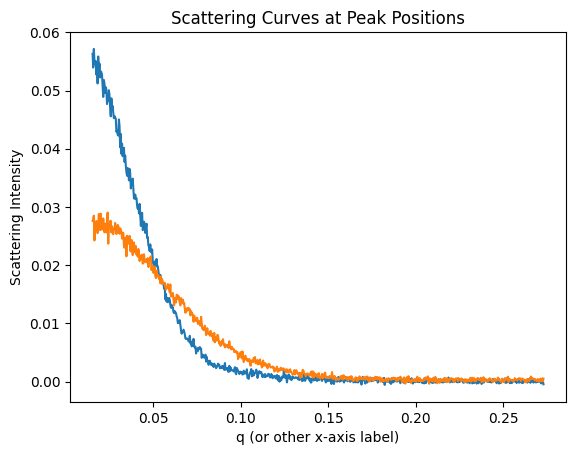

In [9]:
for j in xr_peaks:
    xr_jcurve = ssd.xr.get_jcurve(j=j)
    plt.plot(xr_jcurve.x, xr_jcurve.y)
plt.title('Scattering Curves at Peak Positions')
plt.xlabel('q (or other x-axis label)')
plt.ylabel('Scattering Intensity')
plt.show()

```{note}
You may have noticed that the curves include negative values which are invalid. The treatment of those values will be discussed in the following chapter.  
```

We use `plt.subplots` here because there is no `plt.set_yscale()` function. Let's plot the scattering curves on a logarithmic y-scale for better visualization.

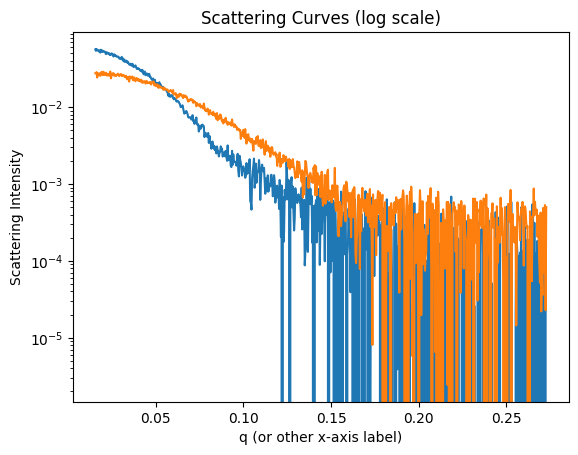

In [10]:
fig, ax = plt.subplots()
ax.set_yscale('log')
for j in xr_peaks:
    xr_jcurve = ssd.xr.get_jcurve(j=j)
    ax.plot(xr_jcurve.x, xr_jcurve.y)
ax.set_title('Scattering Curves (log scale)')
ax.set_xlabel('q (or other x-axis label)')
ax.set_ylabel('Scattering Intensity')
plt.show()

## Python Basics

We assume you are already familiar with Python basics. If not, see the following pages for example.

* [Introduction to Python - QuTiP Tutorial](https://nbviewer.org/urls/qutip.org/qutip-tutorials/tutorials-v5/python-introduction/001_Beginning_Python.ipynb)
* [Introduction to NumPy Arrays - QuTiP Tutorial](https://nbviewer.org/urls/qutip.org/qutip-tutorials/tutorials-v5/python-introduction/002_NumPy_Array_Basics.ipynb)